# Análisis de los barridos en frecuencia (keysight_SA_control)

Junta todos los `.csv` de las carpetas `barrido*` en `LABO 6Y7/` (`barrido(67-1000)`,
`barrido(3k-19k)`, `barrido(22k-49k)`, `barrido(52-195)k`, `barrido 5` a `barrido 9`),
busca el pico de cada traza y arma la curva de amplitud vs. frecuencia de 100 Hz a
14.8 MHz. También reviso un par de cosas raras que aparecen en el camino: la exactitud
en frecuencia del pico, un patrón de bins alternados en la traza cruda, el piso de
ruido/SNR, el ripple, y la forma del pico.

No hace falta el equipo conectado: se lee todo de los `.csv` con pandas.</cell id="936b5a40">

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# mismo estilo que keysight_SA_control.ipynb
matplotlib.rcParams['lines.linewidth'] = 1.2
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['figure.figsize'] = [15, 8]

## 1. Cargar todos los barridos

Busco todas las carpetas que empiecen con `barrido` y tengan `sweep_f_test_*.csv`
adentro, en vez de listarlas a mano. Si se agrega un `barrido 10`, alcanza con
volver a correr el notebook.

Si no hay datos locales (por ejemplo, corriendo esto sin haber clonado el
repo), los busca en GitHub. Para uso normal conviene tener el repo clonado y
hacer `git pull` -- es mucho más rápido y no depende de internet.

In [2]:
# LABO 6Y7/ (un nivel arriba de este notebook, en programar/) -- relativo,
# para que funcione igual en cualquier máquina donde se clone el repo
base_path = Path.cwd().parent

csv_files = sorted(base_path.glob("barrido*/sweep_f_test_*.csv"))
fuentes = [(p.parent.name, p.name, p) for p in csv_files]  # (barrido, archivo, de donde leerlo)

if not fuentes:
    # no hay datos locales (por ejemplo, corriendo esto en Colab sin clonar el
    # repo): se bajan directo de GitHub. Para uso normal conviene "git pull"
    # en vez de esto -- es mucho más rápido y no depende de tener internet.
    import json
    from urllib.parse import quote
    from urllib.request import urlopen

    GITHUB_REPO = "nicolepol/labo6-7-junturas-josephson"
    GITHUB_BRANCH = "main"

    print("No hay datos locales -- los busco en GitHub...")
    api_url = f"https://api.github.com/repos/{GITHUB_REPO}/git/trees/{GITHUB_BRANCH}?recursive=1"
    with urlopen(api_url) as resp:
        tree = json.load(resp)["tree"]

    raw_base = f"https://raw.githubusercontent.com/{GITHUB_REPO}/{GITHUB_BRANCH}/"
    for item in tree:
        ruta = item["path"]
        if re.match(r"^barrido[^/]*/sweep_f_test_.*\.csv$", ruta):
            carpeta, archivo = ruta.split("/", 1)
            fuentes.append((carpeta, archivo, raw_base + quote(ruta, safe="/")))

carpetas = sorted({f[0] for f in fuentes})
print(f"Encontrados {len(fuentes)} archivos en {len(carpetas)} carpetas:")
for c in carpetas:
    print(f"  - {c}")

Encontrados 297 archivos en 9 carpetas:
  - barrido 5
  - barrido 6
  - barrido 7
  - barrido 8
  - barrido 9
  - barrido(22k-49k)
  - barrido(3k-19k)
  - barrido(52-195)k
  - barrido(67-1000)


In [3]:
# el nombre codifica f_test en kHz: sweep_f_test_<f>kHz.csv
f_test_pattern = re.compile(r"sweep_f_test_([\d.]+)kHz\.csv$")


def parse_f_test_hz(nombre_archivo: str) -> float | None:
    m = f_test_pattern.search(nombre_archivo)
    return float(m.group(1)) * 1e3 if m else None


sweeps = []
for i, (barrido, archivo, fuente) in enumerate(fuentes):
    f_test_hz = parse_f_test_hz(archivo)
    if f_test_hz is None:
        # ej. duplicados de OneDrive tipo "... - Copy.csv"
        print(f"  omitido (nombre inesperado): {archivo}")
        continue
    if not isinstance(fuente, Path) and i % 50 == 0:
        print(f"  descargando... ({i}/{len(fuentes)})")
    df = pd.read_csv(fuente)
    sweeps.append({
        "barrido": barrido,
        "archivo": archivo,
        "f_test_hz": f_test_hz,
        "freq": df["Frequency"].to_numpy(),
        "amp": df["Amplitude"].to_numpy(),
    })

# ordenado por f_test para que, recorriendo la lista, salga una sola curva
# continua aunque los barridos se hayan medido por separado
sweeps.sort(key=lambda s: s["f_test_hz"])
raw_traces = {s["archivo"]: (s["freq"], s["amp"]) for s in sweeps}

print(f"Rango total cubierto: {sweeps[0]['f_test_hz']/1e3:.3g} kHz -> "
      f"{sweeps[-1]['f_test_hz']/1e3:.3g} kHz")

  omitido (nombre inesperado): sweep_f_test_0.1kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_0.2kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_0.3kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_0.4kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_0.5kHz - Copy.csv


  omitido (nombre inesperado): sweep_f_test_4.3kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_4.5kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_4.7kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_4.9kHz - Copy.csv
  omitido (nombre inesperado): sweep_f_test_5.1kHz - Copy.csv
Rango total cubierto: 0.1 kHz -> 1.48e+04 kHz


## 2. Buscar el pico en cada traza

Revisando varios archivos a mano, el tono inyectado es siempre el máximo global
de la traza, por lejos: ronda -10 dBm, contra un piso de ruido de entre -80 y
-160 dBm según la carpeta. Con eso alcanza `np.argmax` -- más simple que el
`find_peaks` con umbral que usa `keysight_SA_control.ipynb` (ahí hace falta
porque compara varios picos candidatos dentro de una traza ancha).

Igual calculo el offset entre el pico y `f_test` para poder chequear que esto
siga siendo cierto en cualquier archivo nuevo.

In [4]:
def find_peak(freq, amp, f_test_hz, exclude_bins=5):
    peak_idx = int(np.argmax(amp))
    peak_freq = freq[peak_idx]
    peak_amp = amp[peak_idx]

    # piso de ruido: mediana lejos del pico (si no, el tono contamina la mediana)
    mask = np.ones(len(amp), dtype=bool)
    lo, hi = max(0, peak_idx - exclude_bins), min(len(amp), peak_idx + exclude_bins + 1)
    mask[lo:hi] = False
    noise_floor = np.median(amp[mask])

    return peak_freq, peak_amp, peak_freq - f_test_hz, noise_floor, peak_amp - noise_floor


records = []
for s in sweeps:
    freq_res = float(np.mean(np.diff(s["freq"])))
    peak_freq, peak_amp, offset_hz, noise_floor, snr_db = find_peak(
        s["freq"], s["amp"], s["f_test_hz"]
    )
    records.append({
        "barrido": s["barrido"],
        "archivo": s["archivo"],
        "f_test_hz": s["f_test_hz"],
        "resolucion_hz": freq_res,
        "peak_freq_hz": peak_freq,
        "peak_amp_dbm": peak_amp,
        "offset_hz": offset_hz,
        "offset_en_bins": offset_hz / freq_res,
        "noise_floor_dbm": noise_floor,
        "snr_db": snr_db,
    })

resultados = pd.DataFrame(records).sort_values("f_test_hz").reset_index(drop=True)
resultados.head()

,barrido,archivo,f_test_hz,resolucion_hz,peak_freq_hz,peak_amp_dbm,offset_hz,offset_en_bins,noise_floor_dbm,snr_db
0,barrido(67-1000),sweep_f_test_0.1kHz.csv,100.0,2.0,68.0,-10.179068,-32.0,-16.0,-112.669064,102.489996
1,barrido(67-1000),sweep_f_test_0.2kHz.csv,200.0,2.0,168.0,-10.188841,-32.0,-16.0,-114.116669,103.927828
2,barrido(67-1000),sweep_f_test_0.3kHz.csv,300.0,2.0,268.0,-10.190665,-32.0,-16.0,-113.733013,103.542348
3,barrido(67-1000),sweep_f_test_0.4kHz.csv,400.0,2.0,366.0,-10.192840,-34.0,-17.0,-113.823750,103.630910
4,barrido(67-1000),sweep_f_test_0.5kHz.csv,500.0,2.0,466.0,-10.195993,-34.0,-17.0,-113.595707,103.399714


In [5]:
# si el offset es grande pero el SNR tambien, el pico encontrado sigue siendo
# el tono real (no ruido/armonico) -- solo que no cae donde se esperaba
snr_minimo_confiable = 20  # dB

posible_error_deteccion = resultados[
    (resultados["offset_en_bins"].abs() > 3) & (resultados["snr_db"] < snr_minimo_confiable)
]
offset_alto_snr_alto = resultados[
    (resultados["offset_en_bins"].abs() > 3) & (resultados["snr_db"] >= snr_minimo_confiable)
]

if len(posible_error_deteccion) == 0:
    print("Sin casos de posible detección errónea (offset > 3 bins con SNR bajo).")
else:
    print(f"{len(posible_error_deteccion)} casos con SNR bajo y offset grande -- revisar a mano:")
    display(posible_error_deteccion)

if len(offset_alto_snr_alto) > 0:
    print(f"\n{len(offset_alto_snr_alto)} casos con offset > 3 bins pero SNR alto: el pico es "
          "real, pero no cae en f_test. Carpetas afectadas:",
          sorted(offset_alto_snr_alto["barrido"].unique()))

Sin casos de posible detección errónea (offset > 3 bins con SNR bajo).

31 casos con offset > 3 bins pero SNR alto: el pico es real, pero no cae en f_test. Carpetas afectadas: ['barrido(67-1000)']


In [6]:
out_path = base_path / "programar" / "resumen_picos_barridos.csv"
resultados.to_csv(out_path, index=False)
print(f"Guardado: {out_path}")

Guardado: C:\Users\nikip\OneDrive\LABO 6Y7\programar\resumen_picos_barridos.csv


## 3. Amplitud del pico vs. frecuencia

La curva principal: cómo evoluciona el pico medido a lo largo de todo el barrido,
combinando las 9 carpetas (cada una en un color, para ver si hay saltos entre
sesiones de medición).

**¿Qué es la amplitud en dBm?** Potencia absoluta referida a 1 mW:
`P[dBm] = 10·log10(P[mW] / 1 mW)`. -10 dBm son 0.1 mW.

Con la entrada del analizador en 50 Ω se puede pasar a tensión:
`V_rms = sqrt(P·R)`, `Vpp = 2·sqrt(2)·V_rms` para una senoidal. Sirve para
comparar contra lo que se le pidió al generador (`sweep_amplitude = 0.2` Vpp
en `keysight_SA_control.ipynb`).

In [7]:
R_entrada_ohm = 50
amplitud_generador_vpp = 0.2  # Vpp, seteada en keysight_SA_control.ipynb

def dbm_a_vpp(p_dbm, r_ohm=R_entrada_ohm):
    p_w = 1e-3 * 10 ** (p_dbm / 10)
    v_rms = np.sqrt(p_w * r_ohm)
    return 2 * np.sqrt(2) * v_rms

amplitud_media_dbm = resultados["peak_amp_dbm"].mean()
vpp_medido = dbm_a_vpp(amplitud_media_dbm)

print(f"Amplitud media medida: {amplitud_media_dbm:.2f} dBm -> {vpp_medido*1e3:.1f} mV pp (sobre {R_entrada_ohm} ohm)")
print(f"Amplitud pedida al generador: {amplitud_generador_vpp*1e3:.1f} mV pp")
print(f"Diferencia: {(vpp_medido - amplitud_generador_vpp)*1e3:+.1f} mV pp "
      f"({20*np.log10(vpp_medido/amplitud_generador_vpp):+.2f} dB)")

Amplitud media medida: -10.30 dBm -> 193.3 mV pp (sobre 50 ohm)
Amplitud pedida al generador: 200.0 mV pp
Diferencia: -6.7 mV pp (-0.30 dB)


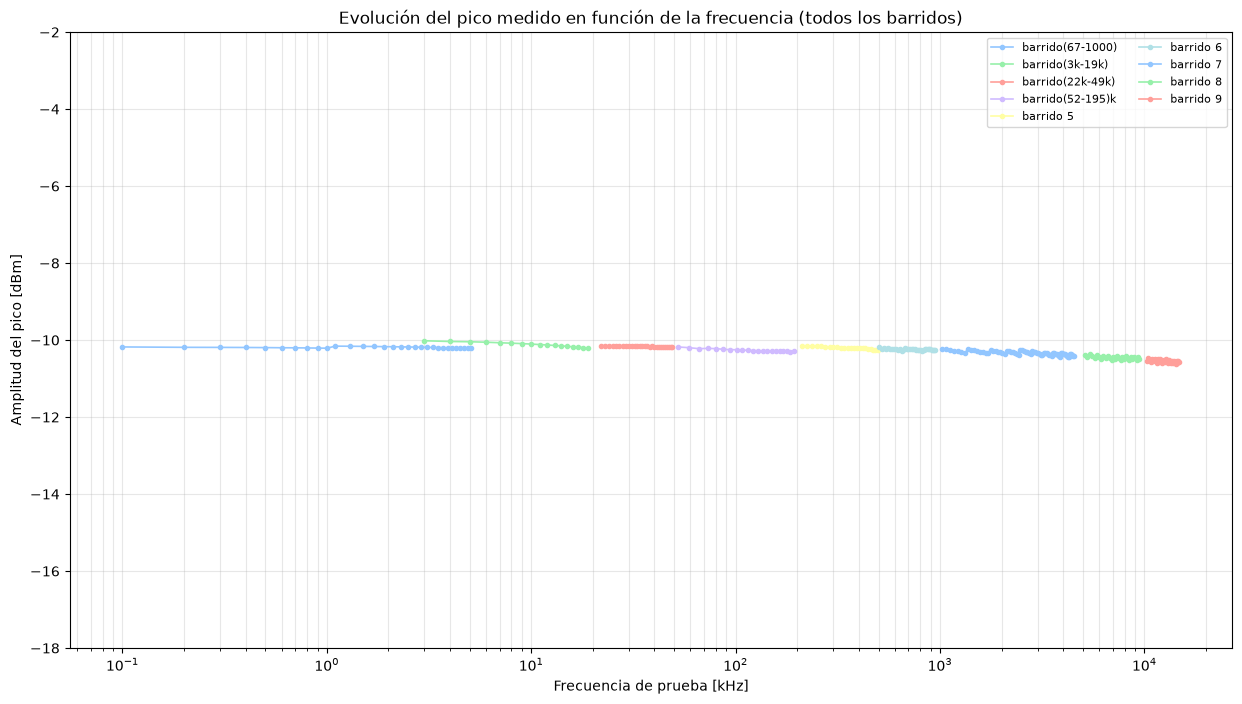

In [8]:
fig, ax = plt.subplots()
for barrido, grupo in resultados.groupby("barrido", sort=False):
    ax.plot(grupo["f_test_hz"] / 1e3, grupo["peak_amp_dbm"], "o-", ms=3, label=barrido)

ax.set_xscale("log")
ax.set_xlabel("Frecuencia de prueba [kHz]")
ax.set_ylabel("Amplitud del pico [dBm]")
ax.set_title("Evolución del pico medido en función de la frecuencia (todos los barridos)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)

# eje Y fijo (no autoescalado): la variación real es <1 dB, y sin fijar el
# rango cualquier ruidito se ve como un dientazo enorme. El detalle fino de
# esa variación se ve en la sección de ripple.
ax.set_ylim(-18, -2)
plt.show()

**Confirmado:** en estos barridos el generador estaba conectado directamente al
analizador de espectro, sin ningún filtro (ni el de temperatura ambiente ni el
criogénico) intercalado. Por eso la curva es plana: es la respuesta propia de
la cadena generador + cables + analizador ("loopback"), no la de un filtro.
Sirve como línea de base: cuando se mida con el filtro puesto, restarle esta
curva (en dB) a la nueva aísla la respuesta real del filtro.

**Nota: por qué se superponen las dos primeras curvas.** `barrido(67-1000)`
llega hasta 5.1 kHz y `barrido(3k-19k)` arranca en 3 kHz -- son las únicas dos
carpetas cuyo rango se solapa (el resto son contiguas, sin repetir
frecuencias). No es un error: son dos sesiones de medición independientes
cubriendo la misma zona, así que sirve de chequeo cruzado (¿coinciden?).

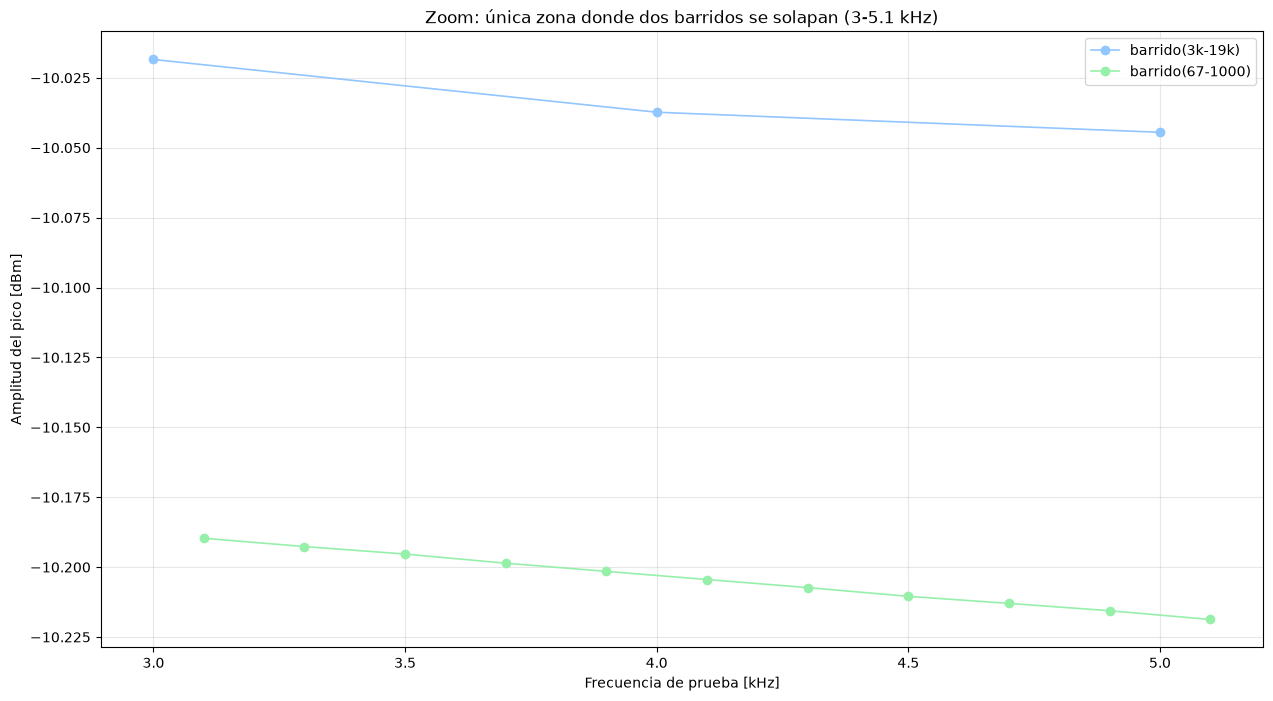

,mean,std
barrido,,
barrido(3k-19k),-10.033420,0.013451
barrido(67-1000),-10.204299,0.009635


In [9]:
solapado = resultados[(resultados["f_test_hz"] >= 3000) & (resultados["f_test_hz"] <= 5100)]

fig, ax = plt.subplots()
for barrido, grupo in solapado.groupby("barrido"):
    ax.plot(grupo["f_test_hz"] / 1e3, grupo["peak_amp_dbm"], "o-", label=barrido)
ax.set_xlabel("Frecuencia de prueba [kHz]")
ax.set_ylabel("Amplitud del pico [dBm]")
ax.set_title("Zoom: única zona donde dos barridos se solapan (3-5.1 kHz)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

solapado.groupby("barrido")["peak_amp_dbm"].agg(["mean", "std"])

Coinciden dentro de ~0.17 dB, compatible con el ripple general (~0.13 dB de
desvío estándar en toda la curva) -- las dos sesiones de medición son
consistentes entre sí, más allá de la diferencia de resolución.

## 4. Exactitud en frecuencia del pico

Diferencia entre dónde aparece el pico (f_pico) y la frecuencia que le pedimos
al generador (f_test), en Hz y en bins (para comparar barridos con paso muy
distinto, de 2 Hz a 25 kHz).

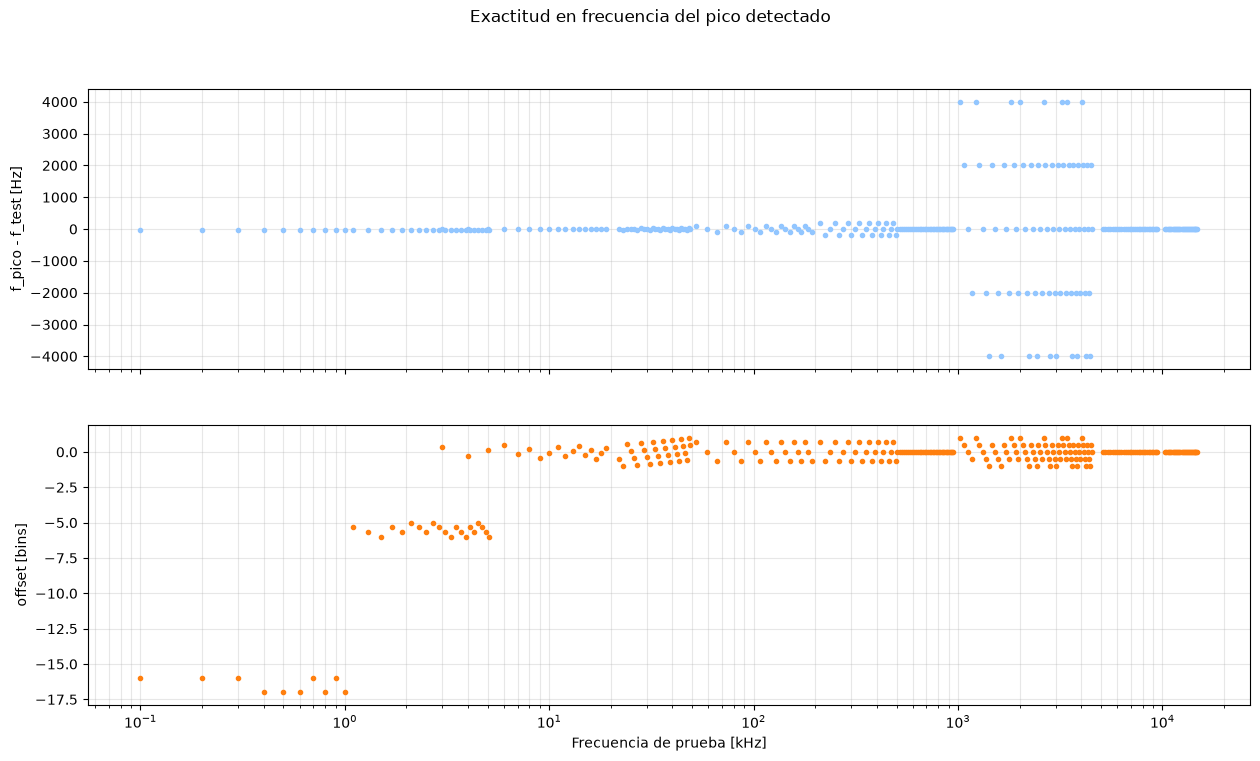

In [10]:
fig, axs = plt.subplots(2, 1, sharex=True)

axs[0].plot(resultados["f_test_hz"] / 1e3, resultados["offset_hz"], ".")
axs[0].set_ylabel("f_pico - f_test [Hz]")
axs[0].grid(True, which="both", alpha=0.3)

axs[1].plot(resultados["f_test_hz"] / 1e3, resultados["offset_en_bins"], ".", color="tab:orange")
axs[1].set_ylabel("offset [bins]")
axs[1].set_xlabel("Frecuencia de prueba [kHz]")
axs[1].set_xscale("log")
axs[1].grid(True, which="both", alpha=0.3)

fig.suptitle("Exactitud en frecuencia del pico detectado")
plt.show()

In [11]:
# agrupo por barrido y resolución (una misma carpeta puede tener mas de un
# paso entre bins) para detectar, en vez de a ojo en el grafico de arriba,
# que grupos tienen un offset sistematico y no solo ruido de cuantizacion
resumen_offset = (
    resultados.groupby(["barrido", "resolucion_hz"])["offset_en_bins"]
    .agg(offset_medio="mean", desvio="std", n="count")
    .reset_index()
)
resumen_offset["sistematico"] = resumen_offset["offset_medio"].abs() > 1

resumen_offset.sort_values("offset_medio", key=abs, ascending=False)

,barrido,resolucion_hz,offset_medio,desvio,n,sistematico
8,barrido(67-1000),2.0,-1.650000e+01,0.527046,10,True
9,barrido(67-1000),6.0,-5.523810e+00,0.326112,21,True
6,barrido(3k-19k),19.0,2.167183e-02,0.299503,17,False
2,barrido 7,4000.0,-2.112676e-02,0.617811,71,False
5,barrido(22k-49k),29.0,-5.947623e-18,0.597996,28,False
0,barrido 5,300.0,0.000000e+00,0.568535,23,False
1,barrido 6,500.0,0.000000e+00,0.000000,35,False
3,barrido 8,5000.0,0.000000e+00,0.000000,30,False
4,barrido 9,5000.0,0.000000e+00,0.000000,31,False
7,barrido(52-195)k,150.0,0.000000e+00,0.557773,21,False


Solo `barrido(67-1000)` sale como sistemático (`sistematico=True`), partido en
dos filas porque esa carpeta usa dos resoluciones distintas (2 Hz para 0.1-1.0
kHz, 6 Hz para 1.1-5.1 kHz): el offset real es siempre de unos -30 a -36 Hz,
así que al dividirlo por resoluciones distintas da dos valores distintos en
bins (~-16 y ~-5.5) -- son la misma anomalía, no dos independientes.

Hipótesis: en esa carpeta el barrido arranca en `f_start = 0 Hz`, con el tono
de prueba cerca del borde inferior de la ventana, donde el "peak search" se
puede correr por la forma asimétrica del filtro de RBW cerca de continua. No
se puede confirmar solo con los datos guardados -- valdría la pena repetir un
par de puntos con `f_start` lejos de 0 Hz la próxima vez.

El resto de los barridos da `sistematico=False` (offset medio menor a 1 bin),
salvo por lo que se ve en la siguiente sección.

## 5. Patrón de bins alternados en la traza cruda

En `barrido 7` el offset toma valores discretos raros (0, ±2000, ±4000 Hz,
ver sección 4). Mirando la traza cruda lejos del tono inyectado, la causa
aparece clara: los bins pares e impares tienen amplitudes sistemáticamente
distintas, con diferencias de decenas de dB -- no es ruido, es demasiado
regular. Esto ya está en el `.csv` guardado, antes de que este notebook toque
nada, así que no es un bug de acá; parece un artefacto del propio equipo o de
la configuración usada en esas sesiones (detector, VBW).

In [12]:
def diff_pares_impares(freq, amp, exclude_bins=10):
    """Diferencia de amplitud (dB) entre bins pares e impares, lejos del pico."""
    peak_idx = int(np.argmax(amp))
    mask = np.ones(len(amp), dtype=bool)
    lo, hi = max(0, peak_idx - exclude_bins), min(len(amp), peak_idx + exclude_bins + 1)
    mask[lo:hi] = False
    idx = np.where(mask)[0]
    return np.mean(amp[idx[idx % 2 == 0]]) - np.mean(amp[idx[idx % 2 == 1]])


resultados["diff_pares_impares_db"] = [
    diff_pares_impares(*raw_traces[archivo]) for archivo in resultados["archivo"]
]

resultados.groupby("barrido")["diff_pares_impares_db"].mean().sort_values(key=abs, ascending=False)

barrido
barrido 8           47.600579
barrido 7           46.254867
barrido 9           46.160555
barrido 6           33.245220
barrido 5           30.722580
barrido(52-195)k    26.437009
barrido(22k-49k)    13.928633
barrido(67-1000)     0.077698
barrido(3k-19k)     -0.008773
Name: diff_pares_impares_db, dtype: float64

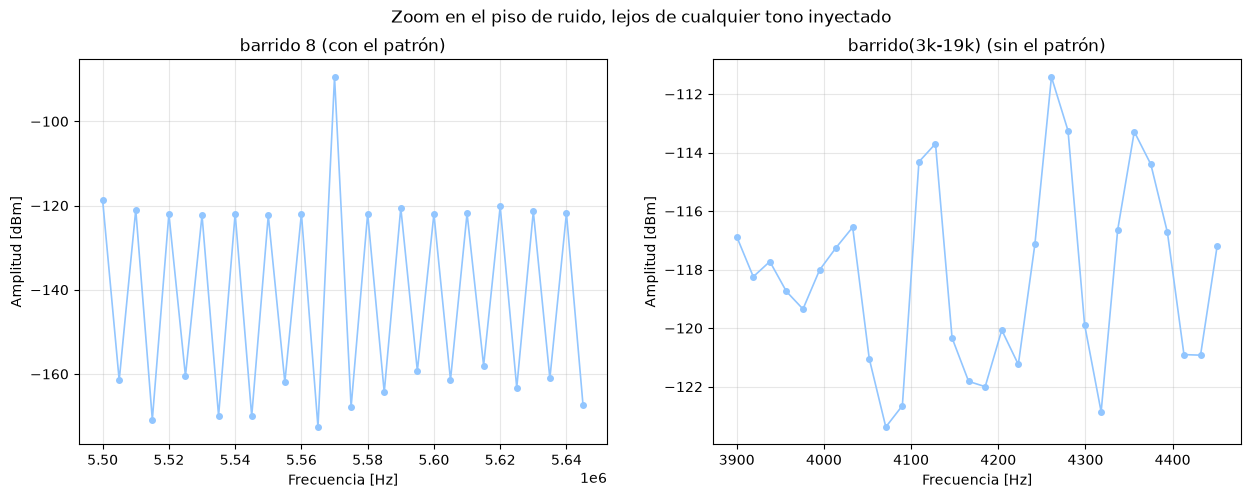

In [13]:
ejemplos = {
    "barrido 8 (con el patrón)": raw_traces["sweep_f_test_7350.0kHz.csv"],
    "barrido(3k-19k) (sin el patrón)": raw_traces["sweep_f_test_10.0kHz.csv"],
}

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for ax, (titulo, (freq, amp)) in zip(axs, ejemplos.items()):
    ax.plot(freq[100:130], amp[100:130], "o-", ms=4)
    ax.set_title(titulo)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Amplitud [dBm]")
    ax.grid(alpha=0.3)

fig.suptitle("Zoom en el piso de ruido, lejos de cualquier tono inyectado")
plt.show()

7 de las 9 carpetas muestran esta diferencia par/impar de forma clara (10 a
casi 50 dB); solo `barrido(3k-19k)` y `barrido(67-1000)` (las dos primeras que
se midieron) salen limpias. Como coincide justo con las dos que no tienen el
offset raro de la sección 4, y las demás sí, queda bastante claro que el
patrón de bins alternados es lo que explica esas bandas extra: cuando `f_test`
cae en un bin "malo" (suprimido), el máximo salta al bin bueno más cercano, a
1 o 2 bins de distancia -- de ahí los saltos de 2000/4000 Hz en `barrido 7`.

Conclusión práctica: en las 7 carpetas afectadas, la resolución en frecuencia
efectiva es el doble de la nominal (solo la mitad de los bins es confiable).
Vale la pena revisar la configuración del analizador (detector, VBW) antes de
la próxima tanda de mediciones para ver si se puede evitar.

## 6. Piso de ruido y SNR

Cómo cambian el piso de ruido y el SNR a lo largo del barrido -- útil para
saber en qué rango la medición va a ser más limpia cuando se mida el filtro
real y la señal esté atenuada.

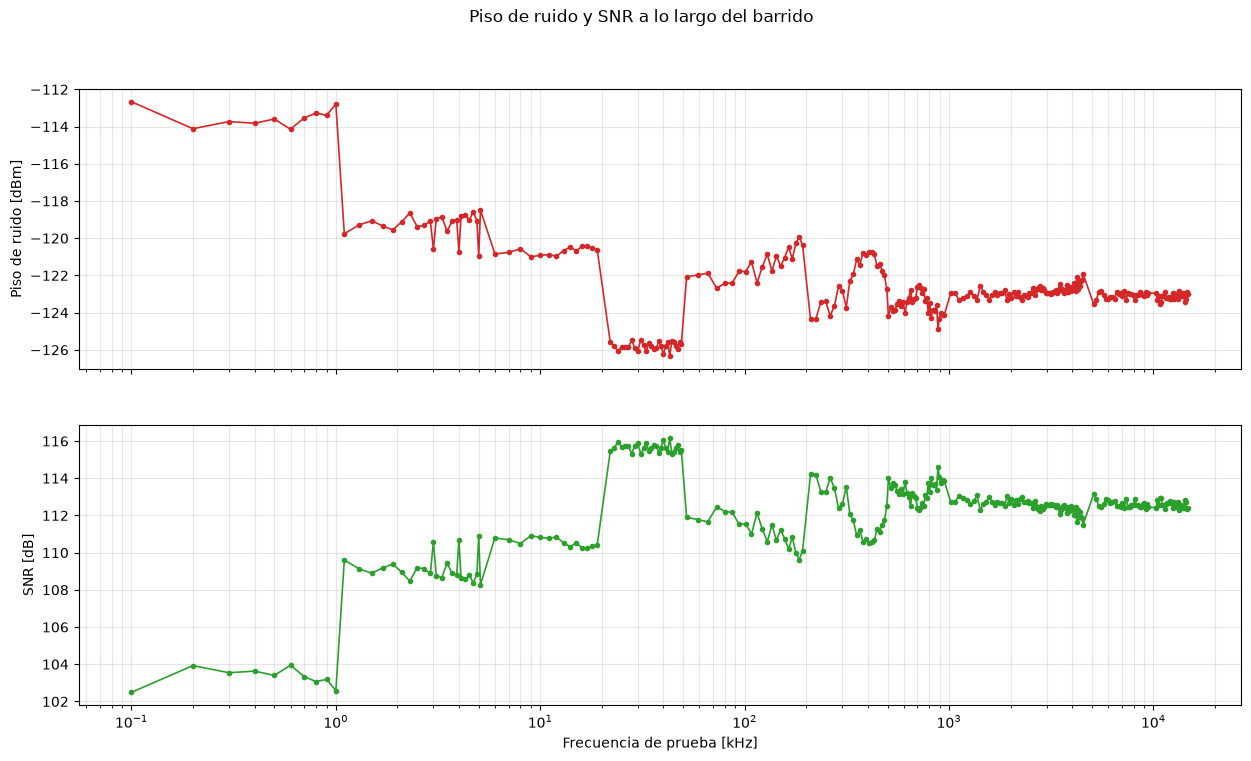

In [14]:
fig, axs = plt.subplots(2, 1, sharex=True)

axs[0].plot(resultados["f_test_hz"] / 1e3, resultados["noise_floor_dbm"], ".-", color="tab:red")
axs[0].set_ylabel("Piso de ruido [dBm]")
axs[0].grid(True, which="both", alpha=0.3)

axs[1].plot(resultados["f_test_hz"] / 1e3, resultados["snr_db"], ".-", color="tab:green")
axs[1].set_ylabel("SNR [dB]")
axs[1].set_xlabel("Frecuencia de prueba [kHz]")
axs[1].set_xscale("log")
axs[1].grid(True, which="both", alpha=0.3)

fig.suptitle("Piso de ruido y SNR a lo largo del barrido")
plt.show()

## 8. Forma del pico por barrido

Un panel por carpeta (no todo superpuesto), con 3 frecuencias representativas
de cada una (primera, media, última), para ver el ancho del pico en bins.

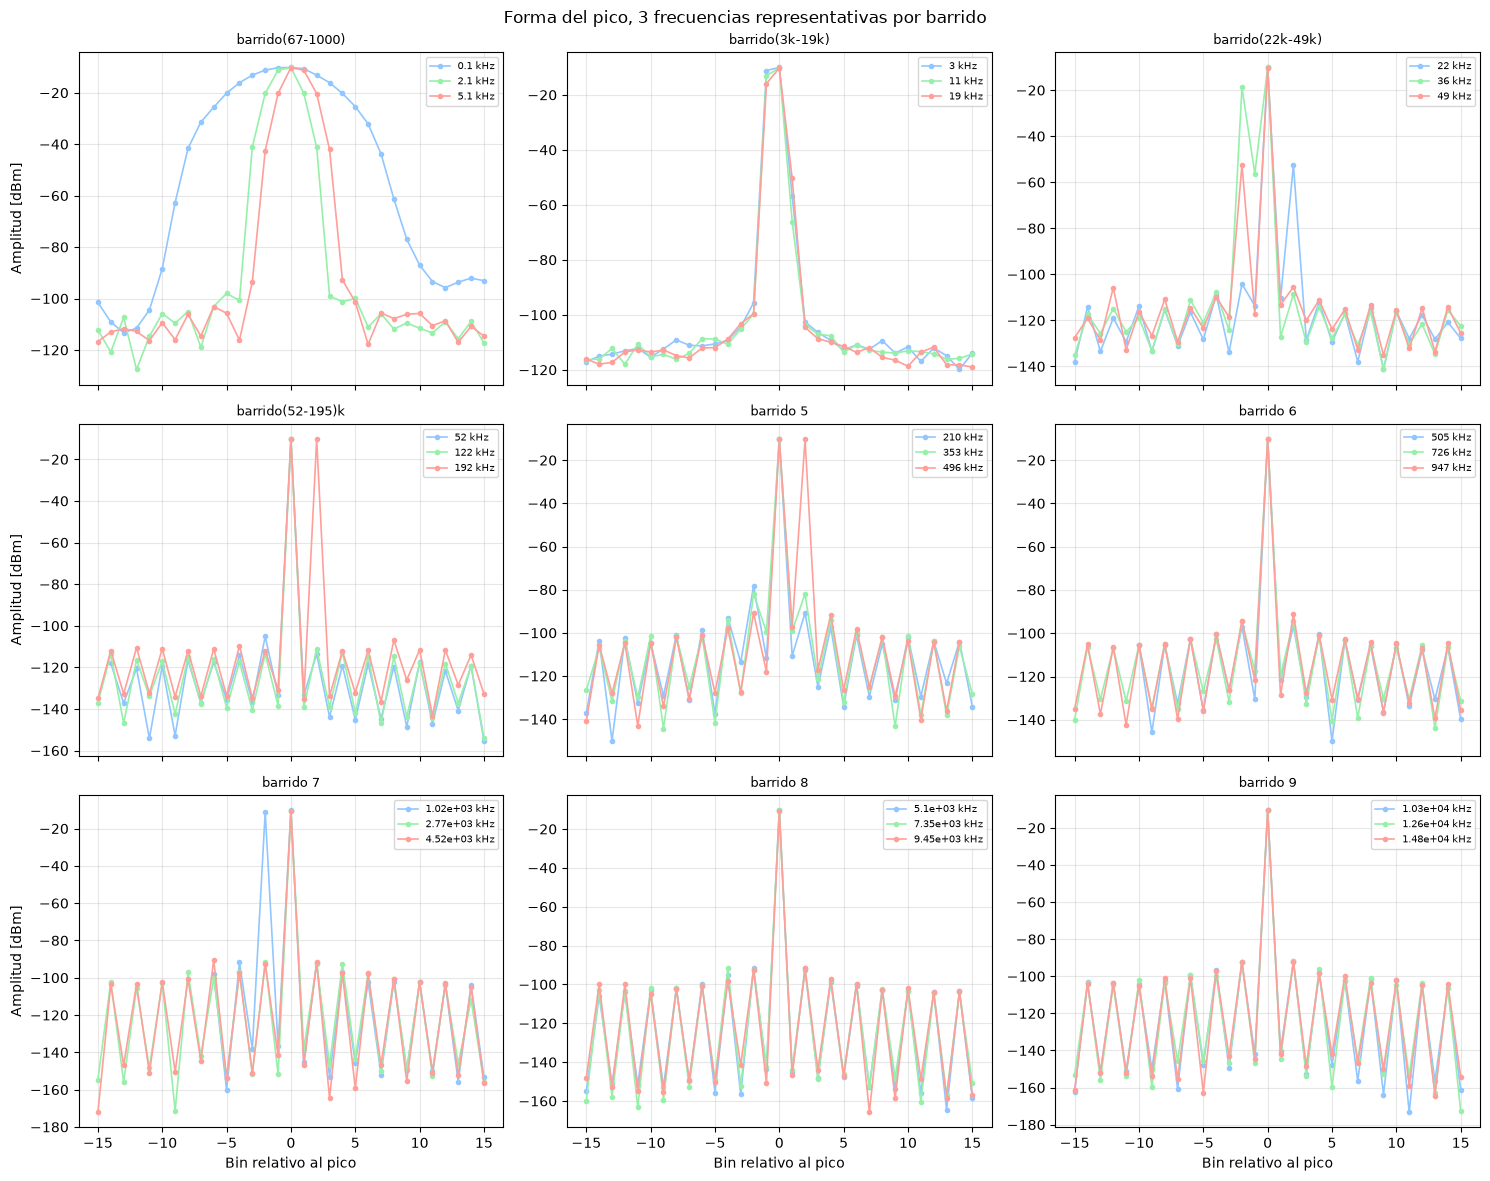

In [15]:
window_bins = 15
barridos = resultados["barrido"].unique()

fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True)

for ax, barrido in zip(axs.flat, barridos):
    grupo = resultados[resultados["barrido"] == barrido]
    for i in (0, len(grupo) // 2, -1):
        row = grupo.iloc[i]
        freq, amp = raw_traces[row["archivo"]]
        peak_idx = int(np.argmax(amp))
        lo = max(0, peak_idx - window_bins)
        hi = min(len(amp), peak_idx + window_bins + 1)
        bins_rel = np.arange(lo, hi) - peak_idx
        ax.plot(bins_rel, amp[lo:hi], marker=".",
                label=f"{row['f_test_hz']/1e3:.3g} kHz")
    ax.set_title(barrido, fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

for ax in axs[-1, :]:
    ax.set_xlabel("Bin relativo al pico")
for ax in axs[:, 0]:
    ax.set_ylabel("Amplitud [dBm]")

fig.suptitle("Forma del pico, 3 frecuencias representativas por barrido")
fig.tight_layout()
plt.show()

## Conclusiones

**Sobre el instrumental (esto es lo que realmente se midió acá):**

- La cadena generador + cables + analizador es plana dentro de <1.5 dB en las
  5 décadas medidas (100 Hz a 14.8 MHz) -- confirma que el setup de medición
  en sí no mete ninguna resonancia o atenuación rara en ese rango.
- La amplitud medida (-10.3 dBm de promedio) coincide con los 200 mVpp
  pedidos al generador dentro de 0.3 dB: no hay pérdida apreciable en cables
  ni conectores.
- El pico se identifica sin ambigüedad en las ~290 trazas (SNR > 20 dB
  siempre, típicamente > 100 dB).

**Dos problemas de calibración/adquisición para tener en cuenta la próxima vez:**

- `barrido(67-1000)` (100 Hz - 5.1 kHz) tiene un offset sistemático de pico de
  ~30-36 Hz, de origen no confirmado (hipótesis: efecto de borde por arrancar
  el span en 0 Hz).
- 7 de las 9 carpetas (todas menos `barrido(67-1000)` y `barrido(3k-19k)`, las
  dos primeras medidas) tienen un patrón de bins alternados en la traza cruda
  -- la mitad de los bins queda sistemáticamente suprimida, entre 10 y ~50 dB
  por debajo de lo que debería. Está en el `.csv` guardado, no es algo que
  introduzca este notebook. Reduce a la mitad la resolución en frecuencia
  efectiva de esas carpetas y explica los offsets discretos raros que
  aparecen en la sección 4. Convendría revisar la config del SA (detector,
  VBW) antes de medir de nuevo.

**Para la próxima medición (ya con el filtro conectado):** como acá no hay
ningún filtro en el camino de señal, esta curva sirve de línea de base. El
notebook queda genérico (solo busca carpetas `barrido*/sweep_f_test_*.csv`),
así que alcanza con volver a correrlo sobre los datos nuevos; restándole esta
curva (en dB) se aísla la respuesta real del filtro. Quedó guardada la tabla
completa en `programar/resumen_picos_barridos.csv`.